In [ ]:
import torch
from torch.utils.data import random_split
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

full_dataset = datasets.MNIST(root='../ML2_Data', train=True, transform=transform, download=True)

Logistic

In [22]:
from torch.utils.data import Subset

# Filter indices for digits 0 and 1 to new dataset
indices_01 = [i for i, (_, y) in enumerate(full_dataset) if y in (0, 1)]
binary_dataset = Subset(full_dataset, indices_01)

print(f"Full dataset size: {len(full_dataset)}")
print(f"Binary dataset (0 and 1) size: {len(binary_dataset)}")

Full dataset size: 60000
Binary dataset (0 and 1) size: 12665


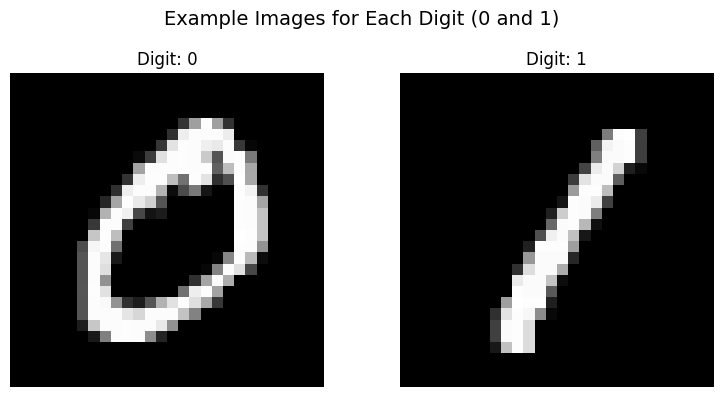

In [ ]:
import matplotlib.pyplot as plt

# Store one example image for each digit 
examples = {}
for img, label in binary_dataset:
    if label not in examples: 
        examples[label] = img
    if len(examples) == 2: 
        break

# Plotting
plt.figure(figsize=(8, 4))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(examples[i].view(28, 28), cmap='gray')  # reshape to 28*28 image
    plt.title(f"Digit: {i}")
    plt.axis('off')

plt.suptitle("Example Images for Each Digit (0 and 1)", fontsize=14)
plt.subplots_adjust(top=0.8) 
plt.tight_layout()
plt.show()


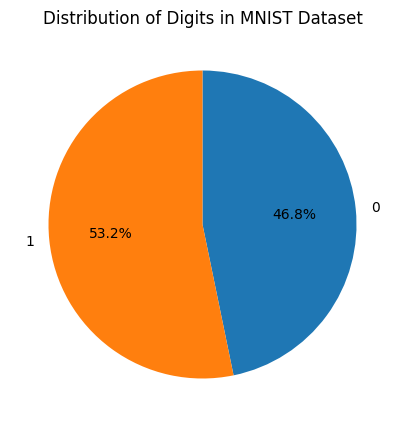

In [ ]:

# Get labels
labels = [label for _, label in binary_dataset]

# Count how many times each label appears
unique_labels, counts = torch.unique(torch.tensor(labels), return_counts=True)

# Plotting
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=unique_labels.tolist(), autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Distribution of Digits in MNIST Dataset")
plt.show()

In [23]:
# Split binary dataset into 60% train, 20% val, 20% test
train_size = int(0.6 * len(binary_dataset))
val_size   = int(0.2 * len(binary_dataset))
test_size  = len(binary_dataset) - train_size - val_size

train_dataset_bin, val_dataset_bin, test_dataset_bin = torch.utils.data.random_split(
    binary_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducibility
)

# Get one sample to inspect
x_sample, y_sample = binary_dataset[0]
feature_dim = x_sample.numel()

# Print dataset information
print("Binary Dataset Summary\n")
print(f"Total samples:        {len(binary_dataset)}")
print(f"Training samples:     {len(train_dataset_bin)}")
print(f"Validation samples:   {len(val_dataset_bin)}")
print(f"Test samples:         {len(test_dataset_bin)}")
print(f"Feature dimension:    {feature_dim}")
print(f"Sample tensor shape:  {tuple(x_sample.shape)}")
print(f"Example label:        {y_sample}")


Binary Dataset Summary

Total samples:        12665
Training samples:     7599
Validation samples:   2533
Test samples:         2533
Feature dimension:    784
Sample tensor shape:  (784,)
Example label:        0


In [29]:
from torch.utils.data import DataLoader

# Create DataLoaders for binary classification
train_loader_bin = DataLoader(train_dataset_bin, batch_size=64, shuffle=True)
val_loader_bin   = DataLoader(val_dataset_bin, batch_size=64, shuffle=False)
test_loader_bin  = DataLoader(test_dataset_bin, batch_size=64, shuffle=False)

print("DataLoaders created successfully\n")
print("Batch size: 64")
print(f"No. of rain batches: {len(train_loader_bin)}")
print(f"No. of validation batches: {len(val_loader_bin)}")
print(f"No. of test batches: {len(test_loader_bin)}")


DataLoaders created successfully

Batch size: 64
No. of rain batches: 119
No. of validation batches: 40
No. of test batches: 40


Softmax

In [ ]:
train_size = int(0.6 * len(full_dataset))
val_size   = int(0.2 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Get one sample to inspect dimensions
x_sample, y_sample = full_dataset[0]
feature_dim = x_sample.numel()

print("Dataset Summary\n")

print(f"Total samples:        {len(full_dataset)}")
print(f"Training samples:     {len(train_dataset)}")
print(f"Validation samples:   {len(val_dataset)}")
print(f"Test samples:         {len(test_dataset)}")
print(f"Feature dimension:    {feature_dim}")
print(f"Sample tensor shape: {tuple(x_sample.shape)}")
print(f"Example label:        {y_sample}")


Dataset Summary

Total samples:        60000
Training samples:     36000
Validation samples:   12000
Test samples:         12000
Feature dimension:    784
Sample tensor shape: (784,)
Example label:        5


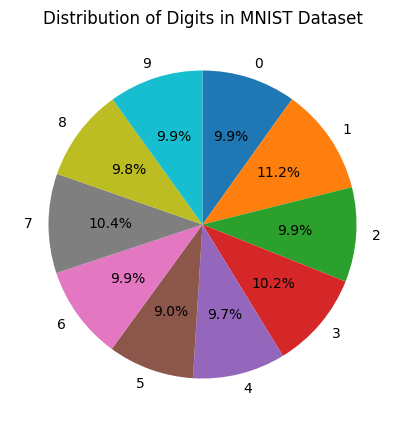

In [ ]:
# Get all labels
labels = [label for _, label in full_dataset]

# Count how many times each label appears
unique_labels, counts = torch.unique(torch.tensor(labels), return_counts=True)

# Plotting
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=unique_labels.tolist(), autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Distribution of Digits in MNIST Dataset")
plt.show()

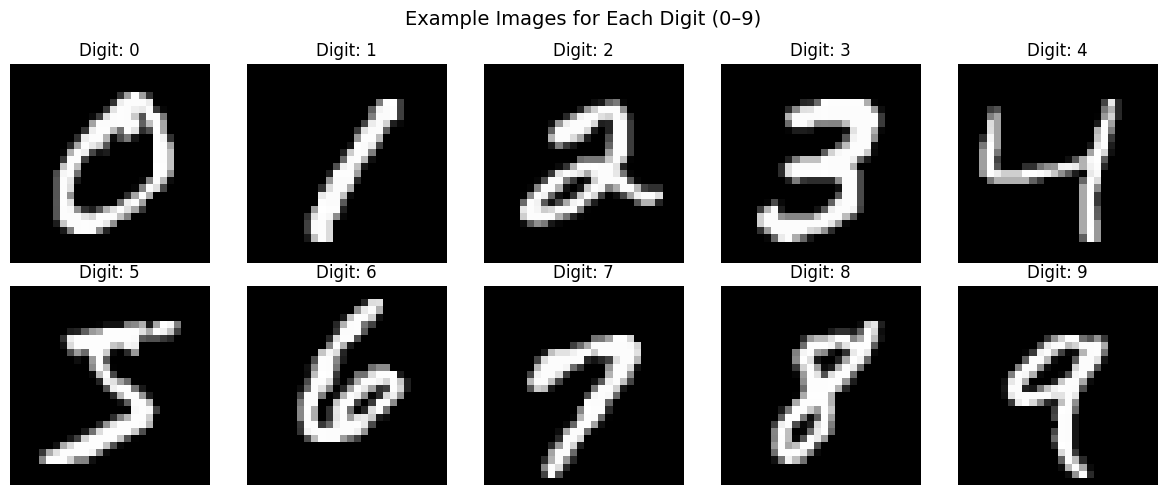

In [ ]:
# Store one example image for each digit 
examples = {}
for img, label in full_dataset:
    if label not in examples: 
        examples[label] = img
    if len(examples) == 10: 
        break

# Plotting
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i].view(28, 28), cmap='gray')  # reshape to 28*28 image
    plt.title(f"Digit: {i}")
    plt.axis('off')

plt.suptitle("Example Images for Each Digit (0–9)", fontsize=14)
plt.tight_layout()
plt.show()

In [30]:

# Create DataLoaders for full 10-class (Softmax) classification
train_loader_full = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_full   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader_full  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders for Full Dataset (Softmax Regression)\n")
print("Batch size: 64")
print(f"No. of training batches:   {len(train_loader_full)}")
print(f"No. of validation batches: {len(val_loader_full)}")
print(f"No. of test batches:       {len(test_loader_full)}")


DataLoaders for Full Dataset (Softmax Regression)

Batch size: 64
No. of training batches:   563
No. of validation batches: 188
No. of test batches:       188
